In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,52,No,Travel_Frequently,322,Research & Development,28,2,Medical,1,1401,...,2,80,1,24,3,2,5,3,0,2
995,43,No,Travel_Rarely,930,Research & Development,6,3,Medical,1,1402,...,1,80,0,20,3,1,20,7,1,8
996,27,No,Travel_Rarely,205,Sales,10,3,Marketing,1,1403,...,4,80,0,6,3,3,6,2,4,4
997,27,Yes,Travel_Rarely,135,Research & Development,17,4,Life Sciences,1,1405,...,4,80,0,8,2,3,8,2,7,7


In [4]:
total_emp = len(df)
print(len(df))

999


In [6]:
(df[df['Attrition'] == 'Yes'].shape[0])

167

In [9]:
print(167/999*100)

16.716716716716718


In [10]:
print(df['MonthlyIncome'].mean())

6616.9039039039035


In [11]:
import matplotlib.pyplot as plt

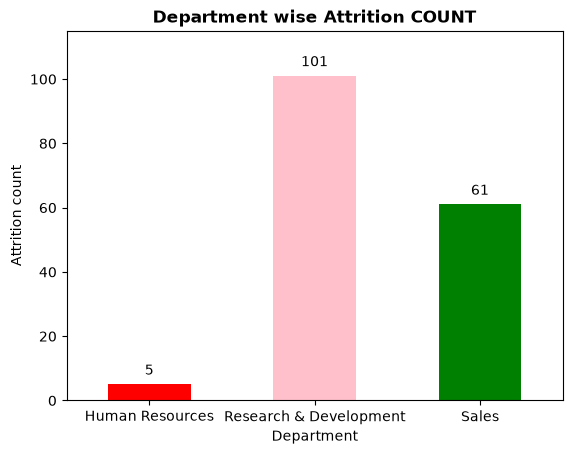

In [42]:
dept_count = df[df['Attrition']=='Yes']['Department'].value_counts()
dept_count = dept_count.reindex(['Human Resources','Research & Development','Sales'])
ax = dept_count.plot(kind='bar', color=['red', 'pink', 'green'])
plt.title('Department wise Attrition COUNT', fontweight='bold')
plt.xlabel('Department')    
plt.ylabel('Attrition count')
plt.xticks(rotation=0)
plt.ylim(0, 115)
for i, v in enumerate(dept_count):
    ax.text(i, v+2, f"{int(v)}", ha='center', va='bottom')
plt.show()

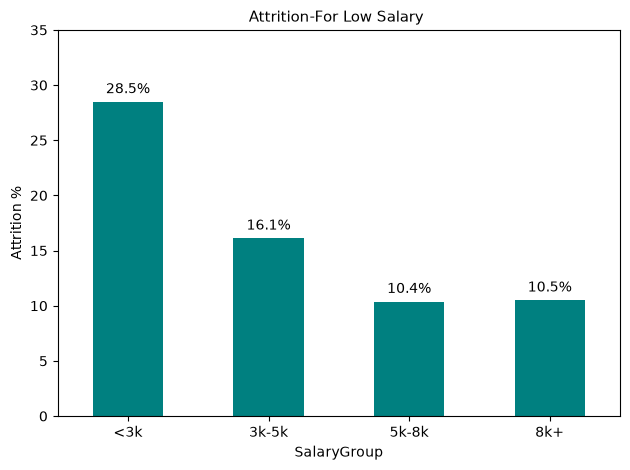

In [34]:
df['SalaryGroup'] = pd.cut(df['MonthlyIncome'], 
                           bins=[0, 3000, 5000, 8000, 20000],
                           labels=['<3k', '3k-5k', '5k-8k', '8k+'])
sal_rate = df.groupby('SalaryGroup', observed=True)['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
ax = sal_rate.plot(kind='bar', color='teal')
plt.title('Attrition-For Low Salary ', fontsize=11)
plt.ylabel("Attrition %")
plt.xticks(rotation=0)
plt.ylim(0, 35)
for i, v in enumerate(sal_rate):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom')
plt.tight_layout()
plt.show()

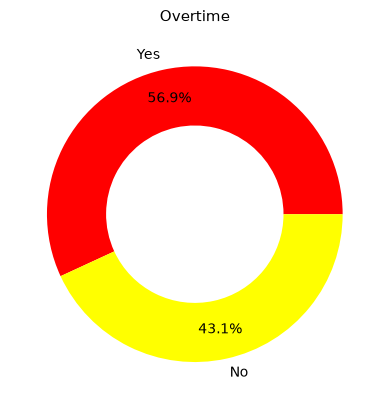

In [46]:
ot = df[df['Attrition']=='Yes']['OverTime'].value_counts()
plt.pie(ot, labels=ot.index, autopct='%1.1f%%', colors=['red','yellow'], wedgeprops={'width':0.4}, pctdistance=0.8)
plt.title('Overtime', fontsize=11)
plt.show()

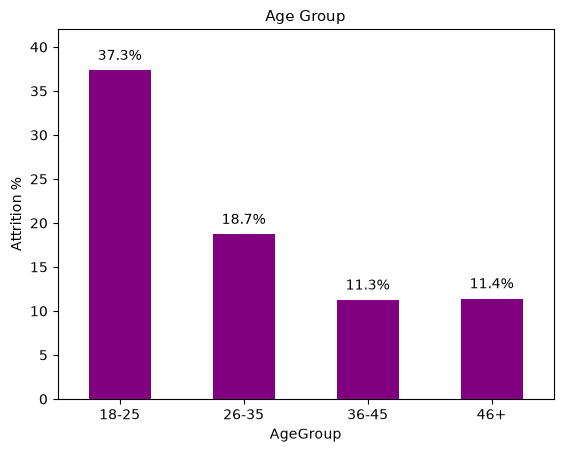

In [51]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,45,60], labels=['18-25','26-35','36-45','46+'])
age_rate = df.groupby('AgeGroup', observed=True)['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
ax = age_rate.plot(kind='bar', color='purple')
plt.title("Age Group", fontsize=11)
plt.ylabel("Attrition %")
plt.xticks(rotation=0)
plt.ylim(0, 42)
for i, v in enumerate(age_rate):
    ax.text(i, v + 0.8, f"{v:.1f}%", ha='center', va='bottom')
plt.show()